# Symbol CNN training

This notebook trains the grayscale UNO symbol CNN, shows the train/validation split, plots the training curves, and reports validation scores plus the confusion matrix.

It uses the existing augmented/split symbol dataset: `augm_symbols_dataset/train.json` for training and `augm_symbols_dataset/test.json` as the held-out validation split.

In [1]:
from collections import Counter
from pathlib import Path
from types import SimpleNamespace
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

notebook_dir = Path.cwd()
if (notebook_dir / "train_cnn.py").exists():
    sys.path.insert(0, str(notebook_dir))
    project_dir = notebook_dir.parent
elif (notebook_dir / "project" / "symbol_classification" / "train_cnn.py").exists():
    sys.path.insert(0, str(notebook_dir / "project" / "symbol_classification"))
    project_dir = notebook_dir / "project"
else:
    raise RuntimeError("Run this notebook from the repo root or project/symbol_classification")

from train_cnn import (
    DEFAULT_DATASET_DIR,
    DEFAULT_OUTPUT_PATH,
    SymbolCNN,
    SymbolDataset,
    choose_device,
    count_trainable_parameters,
    compute_confusion_matrix,
    load_class_mapping,
    print_confusion_matrix,
    run_epoch,
    seed_everything,
)

torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"

('2.8.0+cu128', True, 'NVIDIA GeForce RTX 3090 Ti')

## Configuration

In [2]:
args = SimpleNamespace(
    dataset_dir=DEFAULT_DATASET_DIR,
    train_labels="train.json",
    val_labels="test.json",
    output=DEFAULT_OUTPUT_PATH,
    epochs=25,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    seed=42,
    num_workers=0,
    device="cuda",
    cpu=False,
)

seed_everything(args.seed)
device = choose_device(args)
device

device(type='cuda')

## Dataset and split

In [3]:
class_to_idx = load_class_mapping(args.dataset_dir, (args.train_labels, args.val_labels))
idx_to_class = {idx: label for label, idx in class_to_idx.items()}
train_dataset = SymbolDataset(args.dataset_dir, class_to_idx, args.train_labels)
val_dataset = SymbolDataset(args.dataset_dir, class_to_idx, args.val_labels)

def count_labels(dataset):
    return Counter(idx_to_class[label] for _, label in dataset.samples)

train_counts = count_labels(train_dataset)
val_counts = count_labels(val_dataset)
rows = []
for label in class_to_idx:
    rows.append((label, train_counts[label], val_counts[label], train_counts[label] + val_counts[label]))

print(f"Dataset: {args.dataset_dir}")
print(f"Train labels: {args.train_labels}")
print(f"Validation labels: {args.val_labels}")
print(f"Train images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print("\nlabel      train   val   total")
for label, train_count, val_count, total_count in rows:
    print(f"{label:>8} {train_count:7d} {val_count:5d} {total_count:7d}")

Dataset: C:\Users\ayoub\Code\IAPR_gr69\project\augm_symbols_dataset
Train labels: train.json
Validation labels: test.json
Train images: 4005
Validation images: 2240

label      train   val   total
       0     267   157     424
       1     267   151     418
       2     267   140     407
       3     267   144     411
       4     267   136     403
       5     267   145     412
       6     267   151     418
       7     267   129     396
       8     267   137     404
       9     267   159     426
  draw_2     267   154     421
  draw_4     267   169     436
 reverse     267   154     421
    skip     267   154     421
    wild     267   160     427


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=args.batch_size,
    shuffle=True,
    num_workers=args.num_workers,
    pin_memory=device.type == "cuda",
)
val_loader = DataLoader(
    val_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    pin_memory=device.type == "cuda",
)

## Train

In [5]:
model = SymbolCNN(num_classes=len(class_to_idx)).to(device)
parameter_count = count_trainable_parameters(model)
print(f"Trainable parameters: {parameter_count:,}")
assert parameter_count <= 12_000_000

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args.epochs)

history = []
best_val_acc = 0.0
args.output.parent.mkdir(parents=True, exist_ok=True)

print(f"Training on {device} with {len(train_dataset)} train and {len(val_dataset)} validation images")
for epoch in range(1, args.epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, None, device)
    scheduler.step()

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )
    print(
        f"epoch {epoch:02d}/{args.epochs} "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {
                "model_state": model.state_dict(),
                "class_to_idx": class_to_idx,
                "idx_to_class": idx_to_class,
                "image_size": 64,
                "val_acc": val_acc,
            },
            args.output,
        )

print(f"Best validation accuracy: {best_val_acc:.3f}")
print(f"Saved checkpoint to {args.output}")

Trainable parameters: 141,423
Training on cuda with 4005 train and 2240 validation images
epoch 01/25 train_loss=2.4937 train_acc=0.198 val_loss=2.5213 val_acc=0.158
epoch 02/25 train_loss=2.1566 train_acc=0.341 val_loss=1.9870 val_acc=0.427
epoch 03/25 train_loss=1.8106 train_acc=0.460 val_loss=1.6898 val_acc=0.538
epoch 04/25 train_loss=1.5061 train_acc=0.551 val_loss=1.2798 val_acc=0.784
epoch 05/25 train_loss=1.2587 train_acc=0.649 val_loss=1.0270 val_acc=0.846
epoch 06/25 train_loss=1.0592 train_acc=0.723 val_loss=1.1253 val_acc=0.663
epoch 07/25 train_loss=0.8857 train_acc=0.790 val_loss=0.6941 val_acc=0.912
epoch 08/25 train_loss=0.7511 train_acc=0.832 val_loss=0.6483 val_acc=0.938
epoch 09/25 train_loss=0.6492 train_acc=0.863 val_loss=0.5176 val_acc=0.921
epoch 10/25 train_loss=0.5615 train_acc=0.888 val_loss=0.4721 val_acc=0.959
epoch 11/25 train_loss=0.4873 train_acc=0.907 val_loss=0.5128 val_acc=0.942
epoch 12/25 train_loss=0.4247 train_acc=0.926 val_loss=0.6576 val_acc=0.76

## Training curves

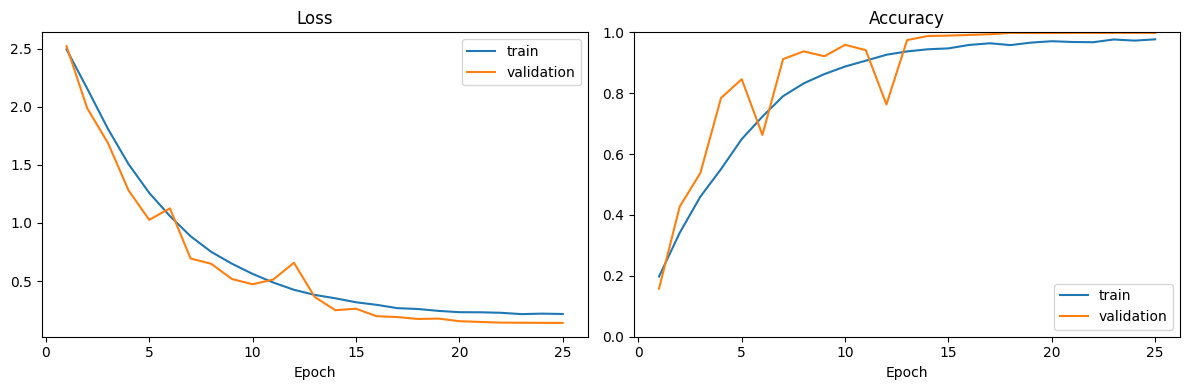

In [6]:
epochs = [row["epoch"] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [row["train_loss"] for row in history], label="train")
axes[0].plot(epochs, [row["val_loss"] for row in history], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, [row["train_acc"] for row in history], label="train")
axes[1].plot(epochs, [row["val_acc"] for row in history], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].legend()
plt.tight_layout()

## Validation scores and confusion matrix

In [7]:
checkpoint = torch.load(args.output, map_location=device)
model.load_state_dict(checkpoint["model_state"])
matrix = compute_confusion_matrix(model, val_loader, len(class_to_idx), device)
print_confusion_matrix(matrix, idx_to_class)

true_positive = matrix.diag().float()
support = matrix.sum(dim=1).float()
predicted = matrix.sum(dim=0).float()
precision = true_positive / predicted.clamp_min(1)
recall = true_positive / support.clamp_min(1)
f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)

overall_acc = true_positive.sum() / matrix.sum().clamp_min(1).float()
macro_f1 = f1.mean()
weighted_f1 = (f1 * support).sum() / support.sum().clamp_min(1)

print("\nValidation scores")
print(f"accuracy:    {overall_acc.item():.3f}")
print(f"macro_f1:    {macro_f1.item():.3f}")
print(f"weighted_f1: {weighted_f1.item():.3f}")

print("\nPer-class validation scores")
print("   label precision recall     f1 support")
for idx, label in idx_to_class.items():
    print(
        f"{label:>8} "
        f"{precision[idx].item():9.3f} "
        f"{recall[idx].item():6.3f} "
        f"{f1[idx].item():6.3f} "
        f"{int(support[idx].item()):7d}"
    )


Validation confusion matrix
Rows=true labels, columns=predicted labels
              0     1     2     3     4     5     6     7     8     9 draw_2 draw_4 reverse  skip  wild
        0   157     0     0     0     0     0     0     0     0     0     0     0     0     0     0
        1     0   151     0     0     0     0     0     0     0     0     0     0     0     0     0
        2     0     0   140     0     0     0     0     0     0     0     0     0     0     0     0
        3     0     0     0   144     0     0     0     0     0     0     0     0     0     0     0
        4     0     0     0     0   136     0     0     0     0     0     0     0     0     0     0
        5     0     0     0     0     0   145     0     0     0     0     0     0     0     0     0
        6     0     0     0     0     0     0   150     0     0     1     0     0     0     0     0
        7     0     3     0     0     0     0     0   126     0     0     0     0     0     0     0
        8     0     0   

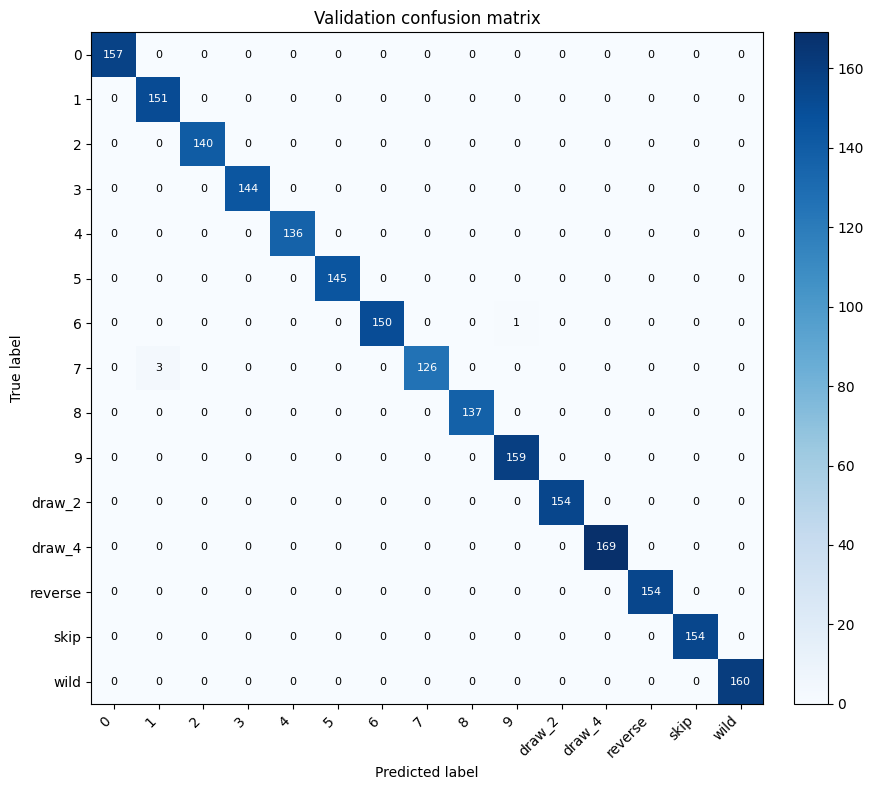

In [8]:
labels = [idx_to_class[idx] for idx in range(len(idx_to_class))]
matrix_np = matrix.numpy()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(matrix_np, cmap="Blues")
ax.set_xticks(np.arange(len(labels)), labels=labels, rotation=45, ha="right")
ax.set_yticks(np.arange(len(labels)), labels=labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Validation confusion matrix")

threshold = matrix_np.max() / 2 if matrix_np.max() else 0
for row in range(matrix_np.shape[0]):
    for col in range(matrix_np.shape[1]):
        value = matrix_np[row, col]
        color = "white" if value > threshold else "black"
        ax.text(col, row, str(value), ha="center", va="center", color=color, fontsize=8)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()